In [10]:
import pandas as pd
df = pd.read_csv('data/WA_Fn-UseC_-HR-Employee-Attrition.csv')
print(df.shape)          # (1470, 35)
print(df.dtypes)
print(df.isnull().sum())
print(df['Attrition'].value_counts())  # check imbalance

(1470, 35)
Age                         int64
Attrition                     str
BusinessTravel                str
DailyRate                   int64
Department                    str
DistanceFromHome            int64
Education                   int64
EducationField                str
EmployeeCount               int64
EmployeeNumber              int64
EnvironmentSatisfaction     int64
Gender                        str
HourlyRate                  int64
JobInvolvement              int64
JobLevel                    int64
JobRole                       str
JobSatisfaction             int64
MaritalStatus                 str
MonthlyIncome               int64
MonthlyRate                 int64
NumCompaniesWorked          int64
Over18                        str
OverTime                      str
PercentSalaryHike           int64
PerformanceRating           int64
RelationshipSatisfaction    int64
StandardHours               int64
StockOptionLevel            int64
TotalWorkingYears           int64
Tra

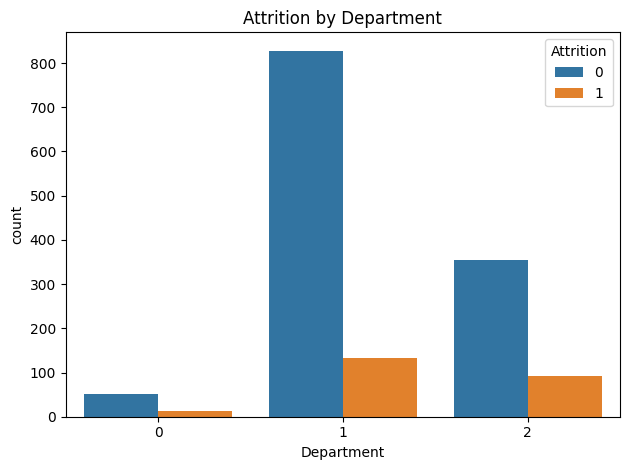

<Axes: >

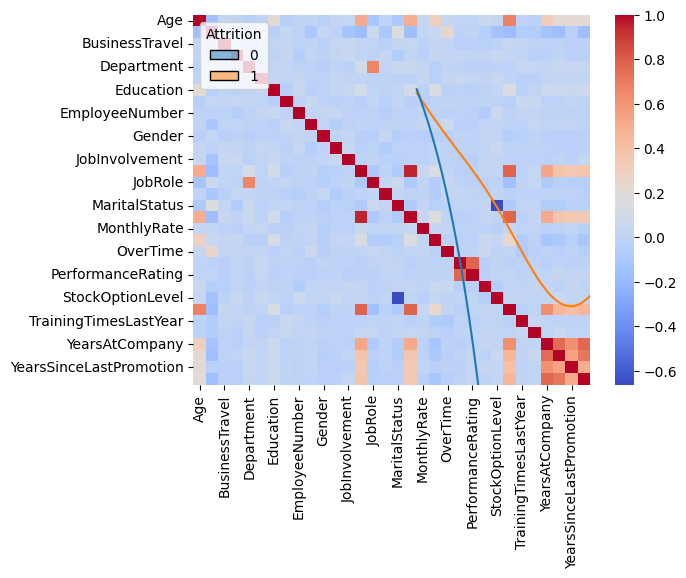

In [21]:
#EDA
import seaborn as sns, matplotlib.pyplot as plt
from pathlib import Path

out = Path("outputs/figures")
out.mkdir(parents=True, exist_ok=True)

# Attrition by department
sns.countplot(data=df, x='Department', hue='Attrition')
plt.title('Attrition by Department')
plt.tight_layout()
plt.savefig(out / "attrition_by_dept.png", dpi=300, bbox_inches="tight")
plt.show()

# Age distribution
sns.histplot(data=df, x='Age', hue='Attrition', kde=True)

# Correlation heatmap (numeric cols only)
sns.heatmap(df.select_dtypes('number').corr(), cmap='coolwarm', annot=False)


In [12]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Drop constant columns
df.drop(['EmployeeCount','Over18','StandardHours'], axis=1, inplace=True)


In [13]:
# Encode target
df['Attrition'] = df['Attrition'].map({'Yes':1,'No':0})

# Encode categoricals
le = LabelEncoder()
cat_cols = df.select_dtypes('object').columns
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

X = df.drop('Attrition', axis=1)
y = df['Attrition']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

C:\Users\SUMANT\AppData\Local\Temp\ipykernel_10456\2502296413.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes('object').columns


In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    print(f"\n{name}")
    print(classification_report(y_test, preds))
    print("ROC-AUC:", roc_auc_score(y_test, model.predict_proba(X_test)[:,1]))


c:\Users\SUMANT\Desktop\hr analysis\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Logistic Regression
              precision    recall  f1-score   support

           0       0.87      0.98      0.92       255
           1       0.25      0.05      0.09        39

    accuracy                           0.85       294
   macro avg       0.56      0.51      0.50       294
weighted avg       0.79      0.85      0.81       294

ROC-AUC: 0.6903971845148316

Random Forest
              precision    recall  f1-score   support

           0       0.88      0.99      0.93       255
           1       0.57      0.10      0.17        39

    accuracy                           0.87       294
   macro avg       0.72      0.55      0.55       294
weighted avg       0.84      0.87      0.83       294

ROC-AUC: 0.7252890899949723

XGBoost
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       255
           1       0.41      0.18      0.25        39

    accuracy                           0.86       294
   macro avg       0.65    

c:\Users\SUMANT\Desktop\hr analysis\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:50:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


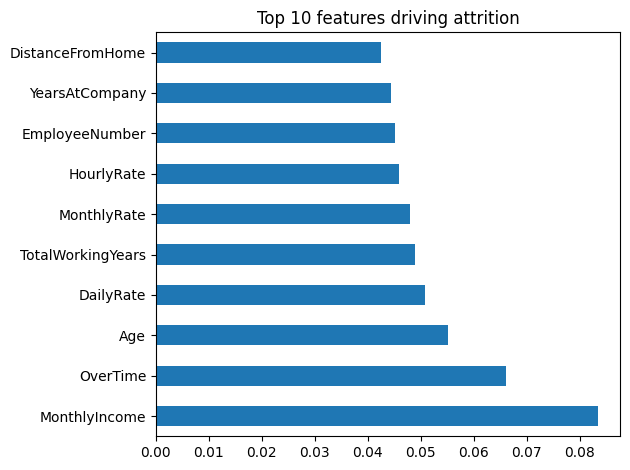

In [15]:
import pandas as pd
rf = models['Random Forest']
feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
feat_imp.nlargest(10).plot(kind='barh', title='Top 10 features driving attrition')
plt.tight_layout()
plt.show()

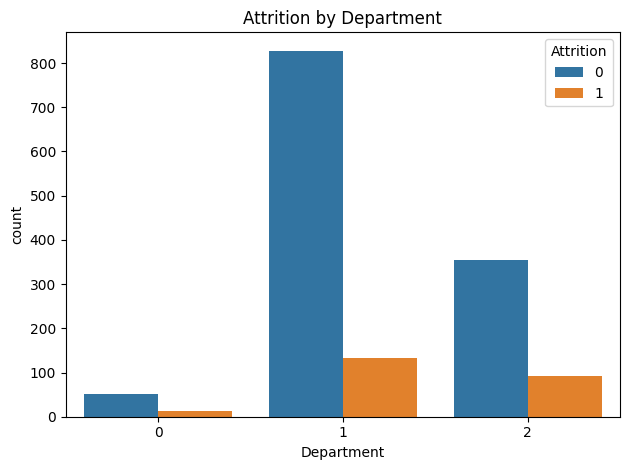

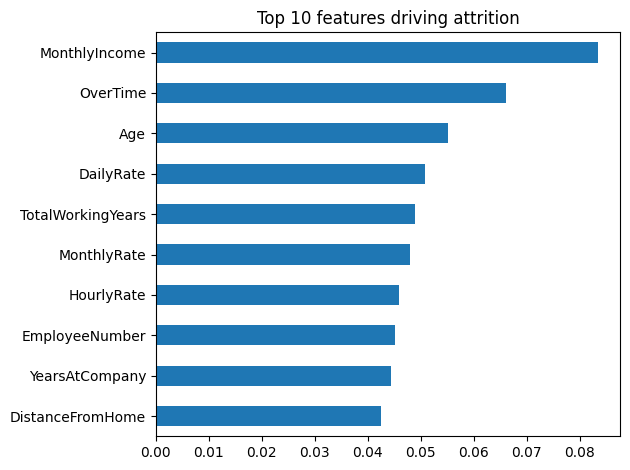

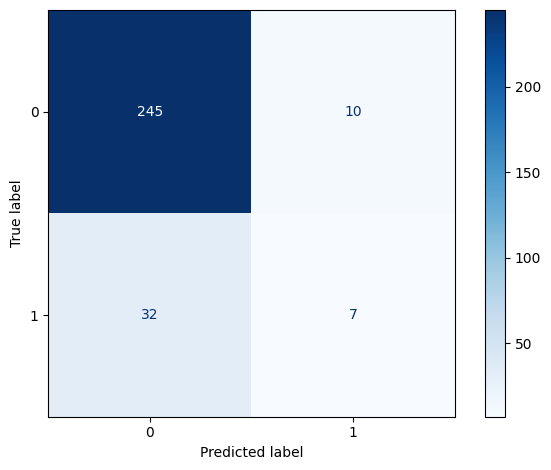

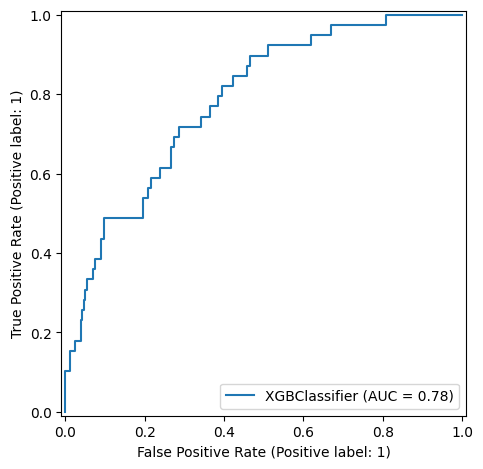

In [ ]:
from pathlib import Path
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

out = Path("outputs/figures")
out.mkdir(parents=True, exist_ok=True)

# 1. Feature importance
rf = models["Random Forest"]
feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
feat_imp.nlargest(10).sort_values().plot(kind="barh", title="Top 10 features driving attrition")
plt.tight_layout()
plt.savefig(out / "feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

# 2. Confusion matrix for final model
xgb = models["XGBoost"]
ConfusionMatrixDisplay.from_estimator(xgb, X_test, y_test, cmap="Blues")
plt.tight_layout()
plt.savefig(out / "confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

# 3. ROC curve for final model
RocCurveDisplay.from_estimator(xgb, X_test, y_test)
plt.tight_layout()
plt.savefig(out / "roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()
